# Learning Effectiveness ML Pipeline - Exploratory Data Analysis

**Project:** ASTAR Learning Method Effectiveness Prediction  
**Data Source:** Canvas LMS + ASTAR Session Behavioral Data  
**Goal:** Understand feature distributions, correlations, and patterns before modeling

## Notebook Contents:
1. Data Loading & Overview
2. Missing Value Analysis
3. Feature Distributions
4. Correlation Analysis
5. Outcome Variable Analysis
6. Behavioral Pattern Exploration
7. Key Insights & Next Steps


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [5]:
# Load training data
data_path = Path('../../data/training_sample.csv')
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 First 5 rows:")
df.head()


📊 Dataset Shape: 33 rows × 25 columns

📋 First 5 rows:


,user_id_hash,assignment_id,course_id,course_name,assignment_name,days_until_due,points_possible,submission_types_count,num_sessions,num_messages,...,session_span_days,early_start_days,message_length_avg,question_ratio,engagement_score,is_completed,submission_status,submission_score,submission_grade,grade_bucket
0,a1b2c3d4e5f6g7h8,101,1001,Computer Science 101,Binary Search Trees,7,100,2,5,45,...,5.0,12.0,125.5,0.267,35.85,1,graded,95.0,A,A
1,a1b2c3d4e5f6g7h8,102,1001,Computer Science 101,Graph Algorithms,3,100,2,8,72,...,7.0,10.0,142.3,0.306,56.86,1,graded,88.0,B+,B
2,a1b2c3d4e5f6g7h8,103,1002,Calculus II,Integration Techniques,-2,50,1,2,15,...,1.0,0.0,98.2,0.200,7.29,0,unsubmitted,NaN,NaN,Unknown
3,b2c3d4e5f6g7h8i9,101,1001,Computer Science 101,Binary Search Trees,7,100,2,3,22,...,4.0,11.0,110.2,0.227,14.93,1,graded,78.0,C+,C
4,b2c3d4e5f6g7h8i9,102,1001,Computer Science 101,Graph Algorithms,3,100,2,6,54,...,6.0,9.0,135.8,0.296,47.03,1,graded,92.0,A-,A


In [6]:
# Data types and info
print("📝 Column Data Types:")
df.info()


📝 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id_hash              33 non-null     object 
 1   assignment_id             33 non-null     int64  
 2   course_id                 33 non-null     int64  
 3   course_name               33 non-null     object 
 4   assignment_name           33 non-null     object 
 5   days_until_due            33 non-null     int64  
 6   points_possible           33 non-null     int64  
 7   submission_types_count    33 non-null     int64  
 8   num_sessions              33 non-null     int64  
 9   num_messages              33 non-null     int64  
 10  avg_messages_per_session  33 non-null     float64
 11  used_step_mode            33 non-null     int64  
 12  num_concepts              33 non-null     int64  
 13  num_context_items         33 non-null     int6

In [7]:
# Summary statistics
print("📈 Numerical Feature Statistics:")
df.describe().T


📈 Numerical Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
assignment_id,33.0,111.818182,8.582156,101.0,104.000,111.000,119.000,127.000
course_id,33.0,1006.939394,5.018338,1001.0,1002.000,1006.000,1011.000,1016.000
days_until_due,33.0,4.666667,5.336588,-6.0,2.000,5.000,8.000,15.000
points_possible,33.0,81.969697,16.533082,50.0,70.000,80.000,100.000,100.000
submission_types_count,33.0,1.484848,0.507519,1.0,1.000,1.000,2.000,2.000
num_sessions,33.0,4.848485,2.670688,0.0,3.000,5.000,7.000,10.000
num_messages,33.0,41.030303,24.098087,0.0,22.000,42.000,58.000,90.000
avg_messages_per_session,33.0,7.973636,1.716484,0.0,8.000,8.400,9.000,9.500
used_step_mode,33.0,0.575758,0.501890,0.0,0.000,1.000,1.000,1.000
num_concepts,33.0,10.121212,5.004733,0.0,7.000,11.000,14.000,20.000


🔍 Missing Values:
                  Missing Count  Percentage
submission_grade             10    30.30303
submission_score             10    30.30303


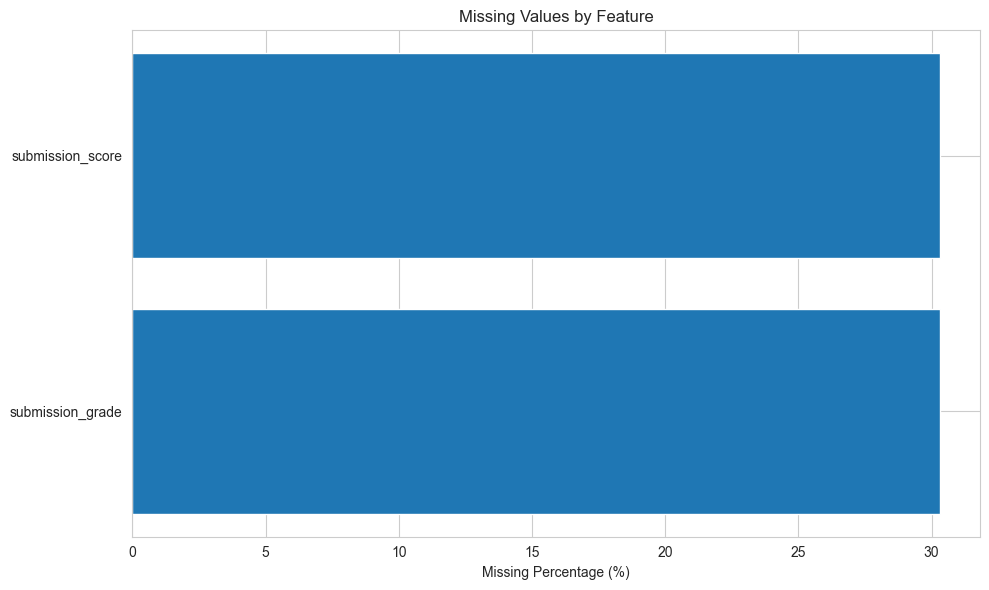

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("🔍 Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 6))
missing_cols = missing_df[missing_df['Missing Count'] > 0]
if len(missing_cols) > 0:
    plt.barh(missing_cols.index, missing_cols['Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Feature')
    plt.tight_layout()
    plt.savefig('../../ml/reports/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("✅ No missing values found!")


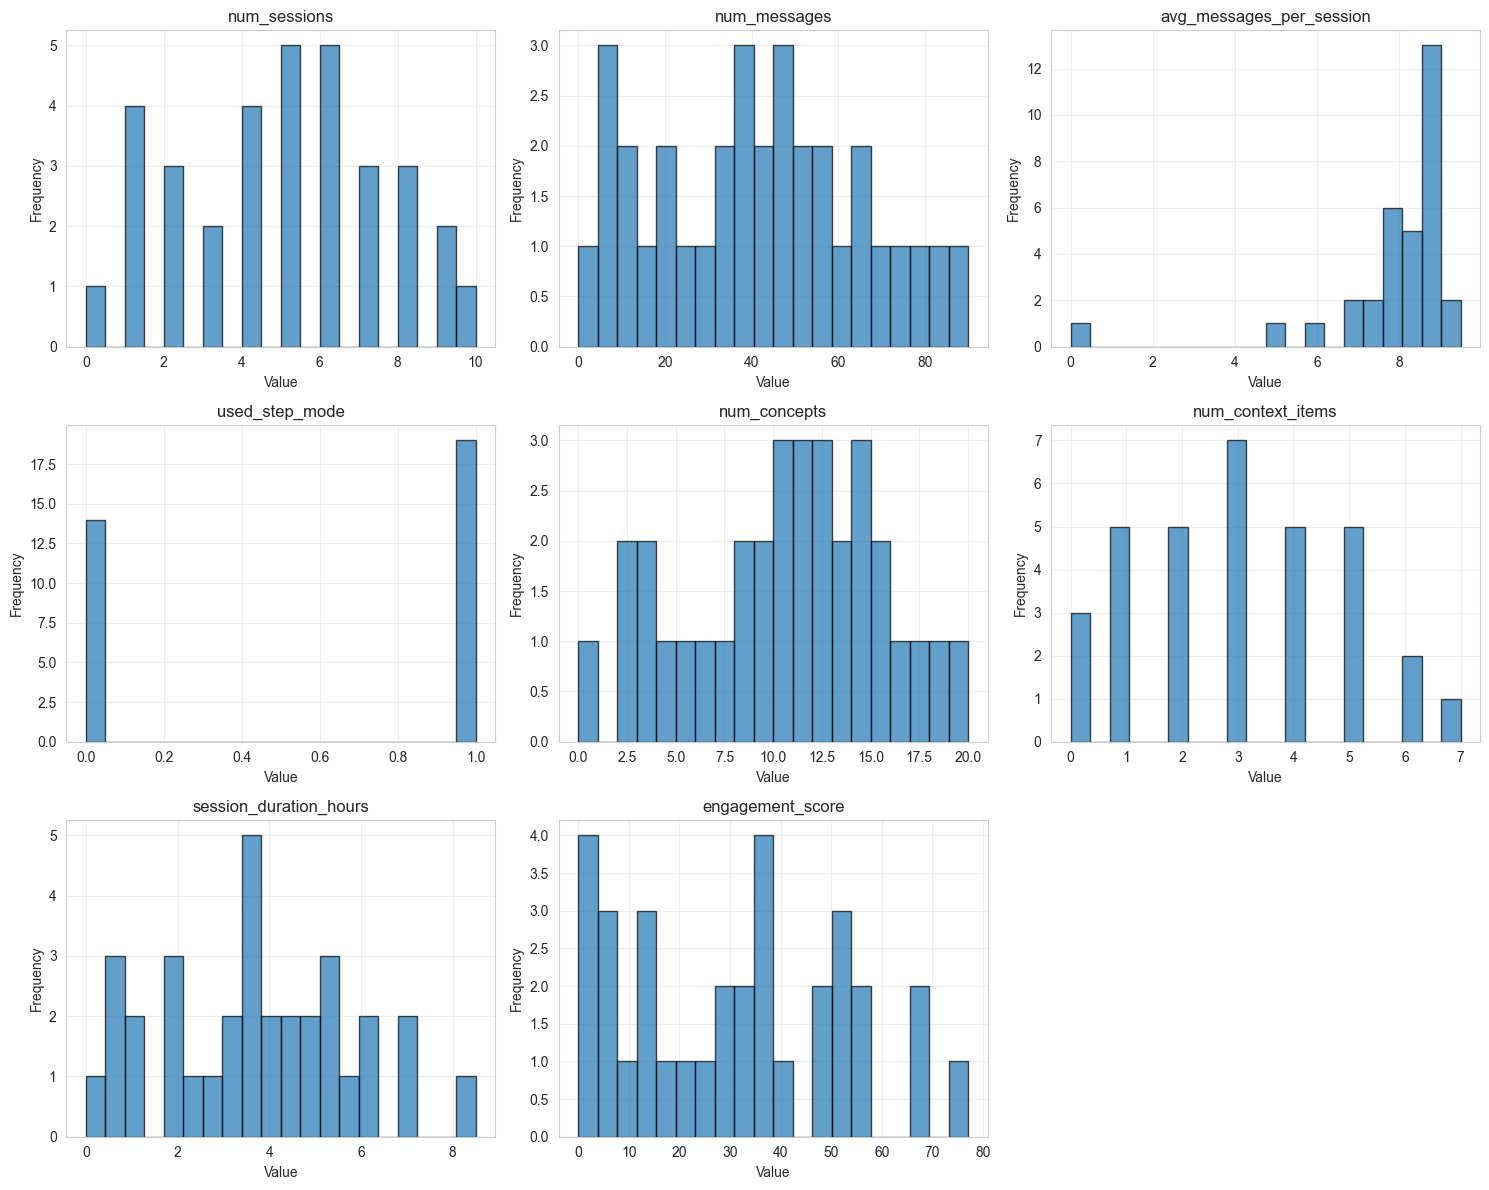

✅ Feature distributions plotted


In [9]:
# Key behavioral features
behavioral_features = [
    'num_sessions', 'num_messages', 'avg_messages_per_session',
    'used_step_mode', 'num_concepts', 'num_context_items',
    'session_duration_hours', 'engagement_score'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(behavioral_features):
    if feature in df.columns:
        axes[idx].hist(df[feature].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{feature}')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(behavioral_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../../ml/reports/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature distributions plotted")


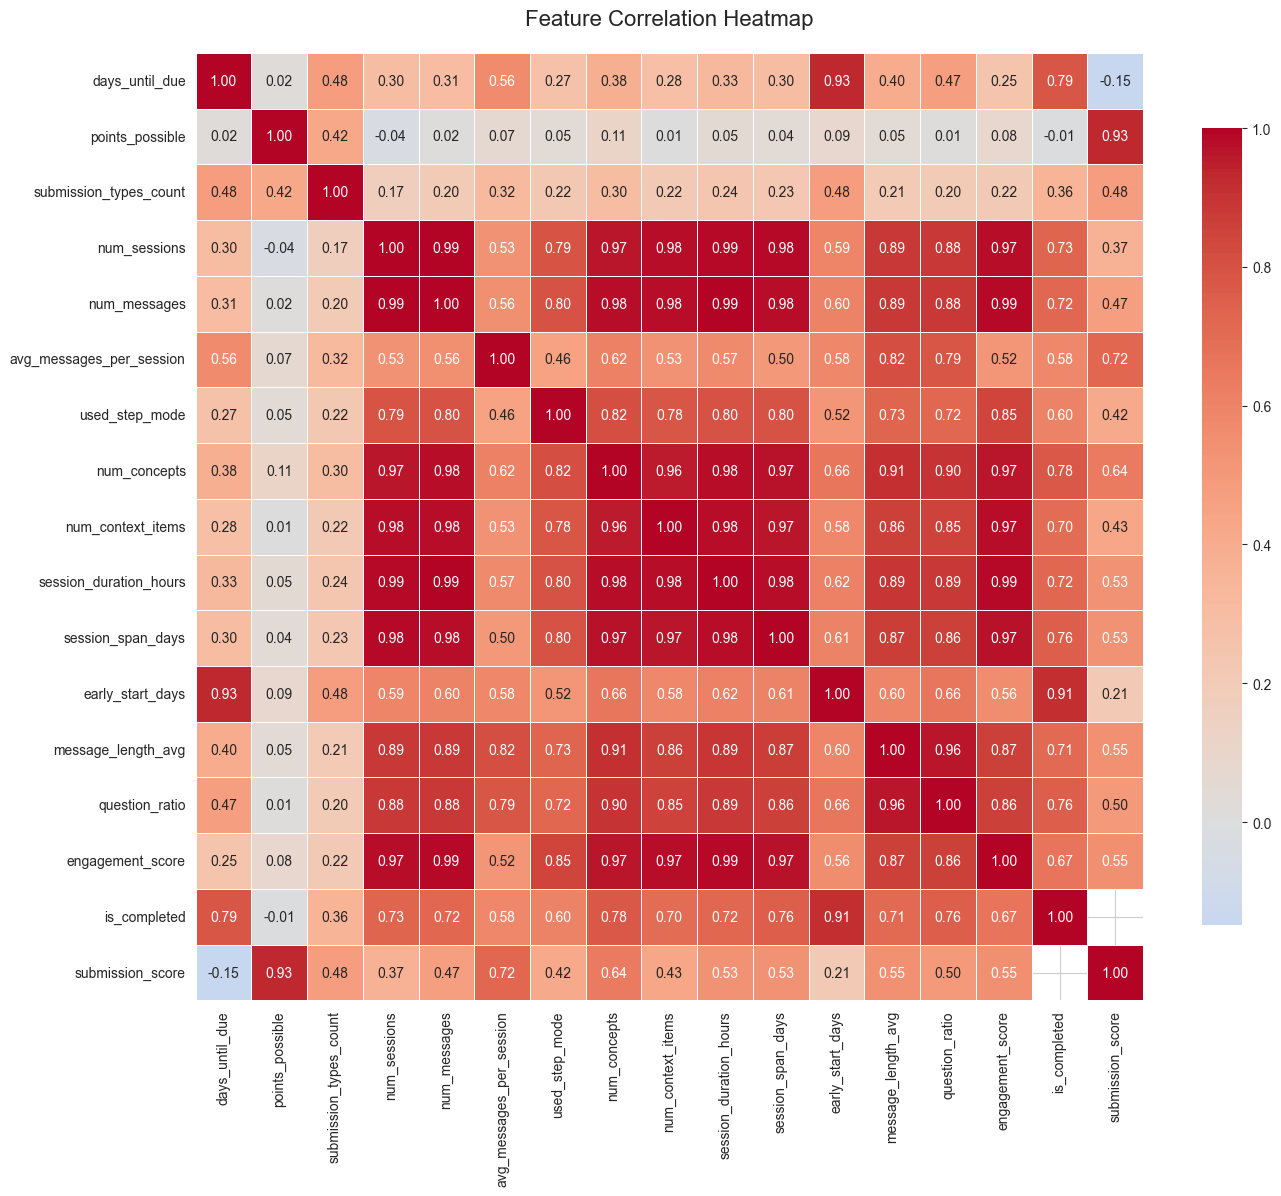


📊 Top Correlations with Assignment Completion:
early_start_days            0.910508
days_until_due              0.785196
num_concepts                0.779833
question_ratio              0.755531
session_span_days           0.755381
num_sessions                0.731110
session_duration_hours      0.723476
num_messages                0.722228
message_length_avg          0.713281
num_context_items           0.695750
engagement_score            0.670821
used_step_mode              0.604471
avg_messages_per_session    0.583932
submission_types_count      0.355064
points_possible            -0.005519
submission_score                 NaN
Name: is_completed, dtype: float64


In [10]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns
numeric_cols = [col for col in numeric_cols if 'id' not in col.lower()]

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../../ml/reports/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Top correlations with is_completed
if 'is_completed' in corr_matrix.columns:
    print("\n📊 Top Correlations with Assignment Completion:")
    completion_corr = corr_matrix['is_completed'].sort_values(ascending=False)
    print(completion_corr[completion_corr.index != 'is_completed'])


📈 Overall Completion Rate: 78.8%


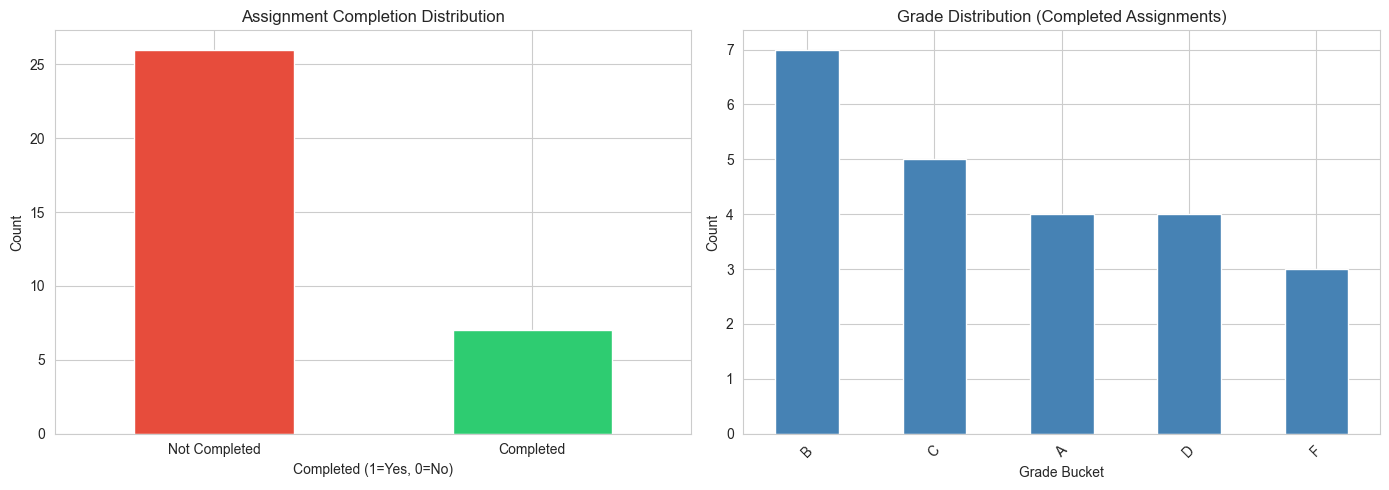

In [11]:
# Assignment completion rate
completion_rate = df['is_completed'].mean() * 100
print(f"📈 Overall Completion Rate: {completion_rate:.1f}%")

# Completion by grade bucket
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Completion distribution
df['is_completed'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Assignment Completion Distribution')
axes[0].set_xlabel('Completed (1=Yes, 0=No)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Completed', 'Completed'], rotation=0)

# Grade bucket distribution (excluding Unknown)
grade_counts = df[df['grade_bucket'] != 'Unknown']['grade_bucket'].value_counts()
grade_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Grade Distribution (Completed Assignments)')
axes[1].set_xlabel('Grade Bucket')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../../ml/reports/outcome_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
